<a href="https://colab.research.google.com/github/Ihsan-ops62/colab-codespace/blob/main/LayoutLMv2/CORD/Prepare_CORD_for_LayoutLMv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis

Let's look at one particular example of the CORD dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


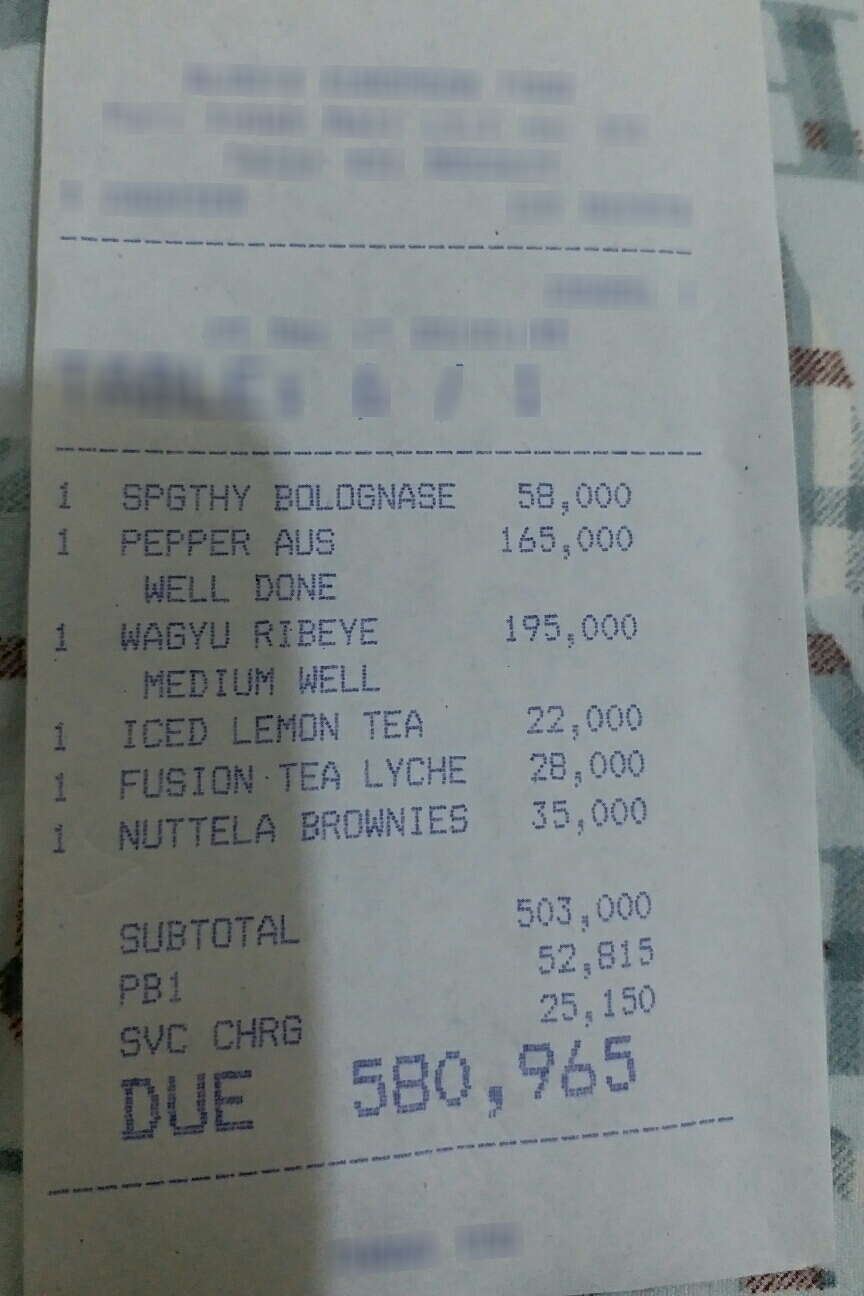

In [19]:
from PIL import Image

image = Image.open('/content/drive/MyDrive/dataset/train/image/receipt_00001.png')
image

Let's read in the corresponding OCR annotations.

In [3]:
import json

with open('/content/drive/MyDrive/dataset/train/json/receipt_00000.json') as json_file:
    data = json.load(json_file)

In [4]:
data.keys()

dict_keys(['dontcare', 'valid_line', 'meta', 'roi', 'repeating_symbol'])

In [5]:
data['meta']

{'version': 'v0.1',
 'split': 'train',
 'image_id': 0,
 'image_size': {'width': 864, 'height': 1296}}

In [6]:
data['roi']

{}

In [7]:
data['repeating_symbol']


[]

This particular example has 93 OCR annotations:

In [8]:
len(data['valid_line'])

93

Let's look at the first one:

In [9]:
data['valid_line'][0]

{'words': [{'quad': {'x2': 270,
    'y3': 390,
    'x3': 270,
    'y4': 390,
    'x1': 256,
    'y1': 374,
    'x4': 256,
    'y2': 374},
   'is_key': 0,
   'row_id': 2179893,
   'text': 'x'}],
 'category': 'menu.cnt',
 'group_id': 3}

Let's annotate the image with the corresponding bounding boxes:

In [20]:
import random

labels = ['menu.cnt',
 'menu.discountprice',
 'menu.etc',
 'menu.itemsubtotal',
 'menu.nm',
 'menu.num',
 'menu.price',
 'menu.sub_cnt',
 'menu.sub_etc',
 'menu.sub_nm',
 'menu.sub_price',
 'menu.sub_unitprice',
 'menu.unitprice',
 'menu.vatyn',
 'sub_total.discount_price',
 'sub_total.etc',
 'sub_total.othersvc_price',
 'sub_total.service_price',
 'sub_total.subtotal_price',
 'sub_total.tax_price',
 'total.cashprice',
 'total.changeprice',
 'total.creditcardprice',
 'total.emoneyprice',
 'total.menuqty_cnt',
 'total.menutype_cnt',
 'total.total_etc',
 'total.total_price',
 'void_menu.nm',
 'void_menu.price']

get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
colors = get_colors(len(labels))
print(colors)

['#821b46', '#8ae4c1', '#487e6e', '#1576f2', '#ac772b', '#fb2592', '#eac721', '#1e0bfc', '#066f96', '#5abfc7', '#642253', '#eada9b', '#bcefd1', '#3bed88', '#81d1bd', '#5b897f', '#12defc', '#354fc5', '#42b860', '#86482d', '#0605a9', '#c44224', '#317408', '#fcb3c4', '#622591', '#bc54ad', '#b787eb', '#feb1cf', '#dcd46a', '#a897db']


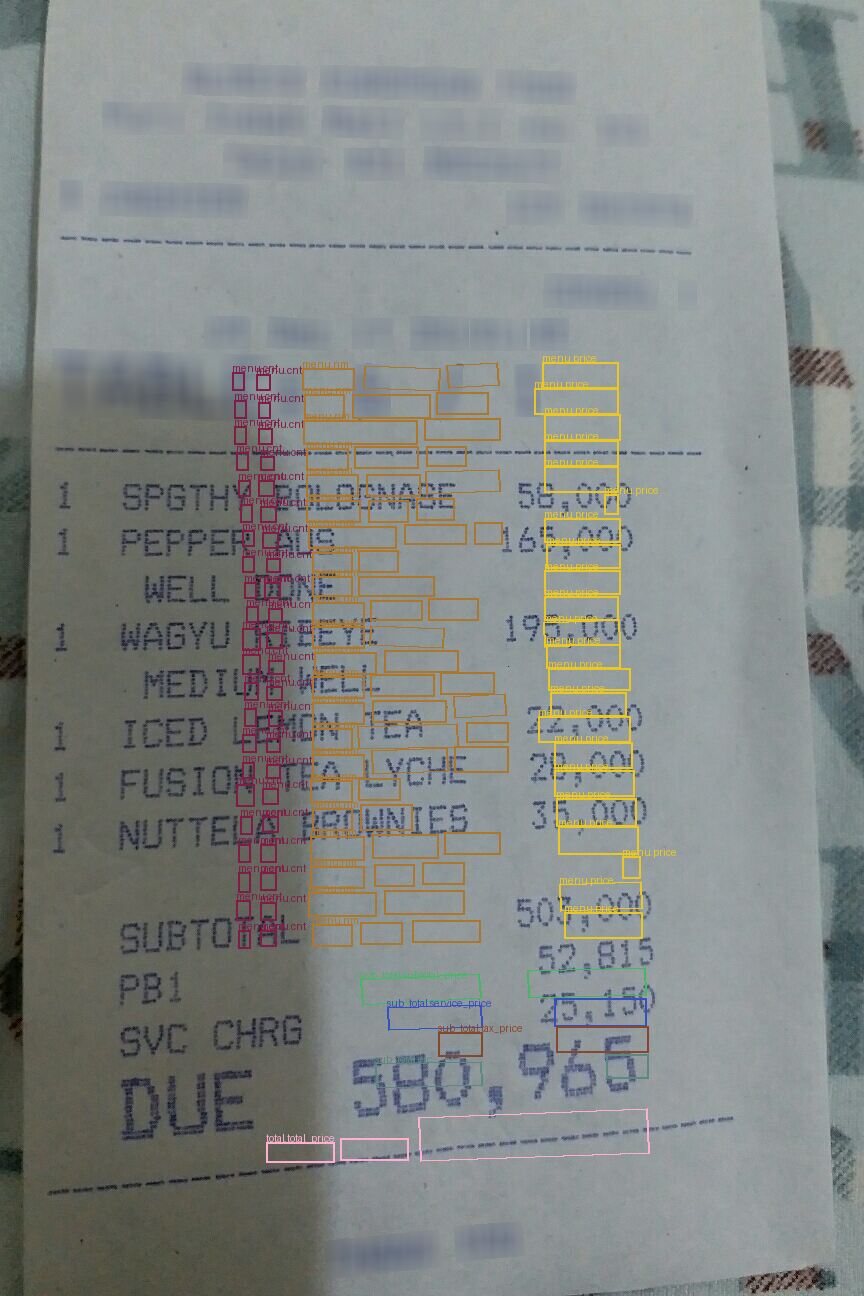

In [21]:
from PIL import ImageDraw, ImageFont

# Initialize drawing context
draw = ImageDraw.Draw(image, "RGBA")
font = ImageFont.load_default()

# Map labels to specific colors for consistency
label2color = {label: colors[idx] for idx, label in enumerate(labels)}

for annotation in data['valid_line']:
    label = annotation['category']
    color = label2color.get(label, "red") # Default to red if label missing

    # Logic Change: Draw the label once per line, not once per word
    # We'll use the first word's position for the label placement
    first_word = True

    for word in annotation['words']:
        # Extract the 4-point quadrilateral (x1,y1, x2,y2, x3,y3, x4,y4)
        q = word['quad']
        polygon = [(q['x1'], q['y1']), (q['x2'], q['y2']),
                   (q['x3'], q['y3']), (q['x4'], q['y4'])]

        # Draw a polygon instead of a rectangle to handle tilt
        draw.polygon(polygon, outline=color, width=2)

        # Place label text only once at the start of the line to avoid clutter
        if first_word:
            draw.text((q['x1'], q['y1'] - 10), label, fill=color, font=font)
            first_word = False

image

# Generating the dataset

In [22]:
from tqdm.notebook import tqdm
import os

def normalize_bbox(bbox, width, height):
     return [
         int(1000 * (bbox[0] / width)),
         int(1000 * (bbox[1] / height)),
         int(1000 * (bbox[2] / width)),
         int(1000 * (bbox[3] / height)),
     ]

def generate_annotations(path: str):
  annotation_files = []
  for js in tqdm(os.listdir(path)):
    with open(path + js) as f:
        annotation_files.append(json.load(f))

  words = []
  boxes = []
  labels = []
  for js in tqdm(annotation_files):
      words_example = []
      boxes_example = []
      labels_example = []

      width, height = js['meta']['image_size']['width'], js['meta']['image_size']['height']
      # loop over OCR annotations
      for elem in js['valid_line']:
          for word in elem['words']:
              # get word
              txt = word['text']

              # get bounding box
              # important: each bounding box should be in (upper left, lower right) format
              # it took me some time to understand the upper left is (x1, y3)
              # and the lower right is (x3, y1)
              x1 = word['quad']['x1']
              y1 = word['quad']['y1']
              x3 = word['quad']['x3']
              y3 = word['quad']['y3']

              box = [x1, y1, x3, y3]
              box = normalize_bbox(box, width=width, height=height)

              # ADDED
              # skip empty word
              if len(txt) < 1:
                continue
              if min(box) < 0 or max(box) > 1000: # another bug in which a box had -4
                continue
              if ((box[3] - box[1]) < 0) or ((box[2] - box[0]) < 0): # another bug in which a box difference was -12
                continue
              # ADDED

              words_example.append(txt)
              boxes_example.append(box)
              labels_example.append(elem['category'])
      words.append(words_example)
      boxes.append(boxes_example)
      labels.append(labels_example)

  return words, boxes, labels

Let's apply the function above for the training, validation and test set:

In [23]:
train_path = '/content/drive/MyDrive/dataset/train/json/'
val_path = '/content/drive/MyDrive/dataset/dev/json/'
test_path = '/content/drive/MyDrive/dataset/test/json/'

words_train, boxes_train, labels_train = generate_annotations(train_path)
words_val, boxes_val, labels_val = generate_annotations(val_path)
words_test, boxes_test, labels_test = generate_annotations(test_path)

  0%|          | 0/787 [00:00<?, ?it/s]

  0%|          | 0/787 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [24]:
labels_train[0]

['menu.nm',
 'menu.cnt',
 'menu.unitprice',
 'menu.price',
 'total.cashprice',
 'total.cashprice',
 'total.changeprice',
 'total.changeprice',
 'sub_total.subtotal_price',
 'sub_total.subtotal_price',
 'sub_total.subtotal_price',
 'sub_total.discount_price']

In [25]:
words_train[0]

['Masker Bengkuang',
 '1',
 '11000',
 '11000',
 'Tunai',
 '11000',
 'Kembalian',
 '0',
 'Sub',
 'Total',
 '11000',
 'Discount (0%)']

In [26]:
boxes_train[0]

[[59, 358, 463, 399],
 [468, 368, 493, 395],
 [62, 395, 194, 425],
 [562, 384, 684, 412],
 [52, 594, 177, 625],
 [565, 611, 690, 641],
 [55, 682, 281, 710],
 [659, 682, 690, 710],
 [52, 483, 145, 513],
 [152, 483, 260, 513],
 [565, 502, 687, 534],
 [48, 539, 364, 574]]

# Saving

In [28]:
import pickle
with open('/content/drive/MyDrive/preprocessed/train.pkl', 'wb') as t:
    pickle.dump([words_train, labels_train, boxes_train], t)
with open('/content/drive/MyDrive/preprocessed/dev.pkl', 'wb') as t:
    pickle.dump([words_val, labels_val, boxes_val], t)
with open('/content/drive/MyDrive/preprocessed/test.pkl', 'wb') as t:
    pickle.dump([words_test, labels_test, boxes_test], t)

In [29]:
import json

# Save as JSON
with open('/content/drive/MyDrive/preprocessed/train.json', 'w') as t:
    json.dump({
        'words': words_train,
        'labels': labels_train,
        'boxes': boxes_train
    }, t, indent=2)

with open('/content/drive/MyDrive/preprocessed/dev.json', 'w') as t:
    json.dump({
        'words': words_val,
        'labels': labels_val,
        'boxes': boxes_val
    }, t, indent=2)

with open('/content/drive/MyDrive/preprocessed/test.json', 'w') as t:
    json.dump({
        'words': words_test,
        'labels': labels_test,
        'boxes': boxes_test
    }, t, indent=2)

In [30]:
import json

# Load from JSON
with open('/content/drive/MyDrive/preprocessed/train.json', 'r') as t:
    train_data = json.load(t)
    words_train = train_data['words']
    labels_train = train_data['labels']
    boxes_train = train_data['boxes']

with open('/content/drive/MyDrive/preprocessed/dev.json', 'r') as t:
    dev_data = json.load(t)
    words_val = dev_data['words']
    labels_val = dev_data['labels']
    boxes_val = dev_data['boxes']

with open('/content/drive/MyDrive/preprocessed/dev.json', 'r') as t:
    test_data = json.load(t)
    words_test = test_data['words']
    labels_test = test_data['labels']
    boxes_test = test_data['boxes']

In [43]:
from datasets import Dataset, DatasetDict, Features, Sequence, ClassLabel, Value
import json

# Load your preprocessed data
with open('/content/drive/MyDrive/preprocessed/train.json', 'r') as f:
    train_data = json.load(f)
with open('/content/drive/MyDrive/preprocessed/dev.json', 'r') as f:
    val_data = json.load(f)
with open('/content/drive/MyDrive/preprocessed/test.json', 'r') as f:
    test_data = json.load(f)

# Get unique labels
all_labels = []
for labels in train_data['labels'] + val_data['labels'] + test_data['labels']:
    all_labels.extend(labels)
unique_labels = sorted(list(set(all_labels)))

# Create label to id mapping
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

print(f"Number of unique labels: {len(unique_labels)}")
print(f"Labels: {unique_labels}")

# Convert string labels to ids
def convert_labels_to_ids(labels_list):
    return [[label2id[label] for label in labels] for labels in labels_list]

# Create dataset features
features = Features({
    'words': Sequence(Value('string')),
    'bboxes': Sequence(Sequence(Value('int64'))),
    'ner_tags': Sequence(ClassLabel(names=unique_labels)),
})

# Create datasets
train_dataset = Dataset.from_dict({
    'words': train_data['words'],
    'bboxes': train_data['boxes'],
    'ner_tags': convert_labels_to_ids(train_data['labels']),
}, features=features)

val_dataset = Dataset.from_dict({
    'words': val_data['words'],
    'bboxes': val_data['boxes'],
    'ner_tags': convert_labels_to_ids(val_data['labels']),
}, features=features)

test_dataset = Dataset.from_dict({
    'words': test_data['words'],
    'bboxes': test_data['boxes'],
    'ner_tags': convert_labels_to_ids(test_data['labels']),
}, features=features)

# Create DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset,
})

print(dataset)

Number of unique labels: 30
Labels: ['menu.cnt', 'menu.discountprice', 'menu.etc', 'menu.itemsubtotal', 'menu.nm', 'menu.num', 'menu.price', 'menu.sub_cnt', 'menu.sub_etc', 'menu.sub_nm', 'menu.sub_price', 'menu.sub_unitprice', 'menu.unitprice', 'menu.vatyn', 'sub_total.discount_price', 'sub_total.etc', 'sub_total.othersvc_price', 'sub_total.service_price', 'sub_total.subtotal_price', 'sub_total.tax_price', 'total.cashprice', 'total.changeprice', 'total.creditcardprice', 'total.emoneyprice', 'total.menuqty_cnt', 'total.menutype_cnt', 'total.total_etc', 'total.total_price', 'void_menu.nm', 'void_menu.price']
DatasetDict({
    train: Dataset({
        features: ['words', 'bboxes', 'ner_tags'],
        num_rows: 787
    })
    validation: Dataset({
        features: ['words', 'bboxes', 'ner_tags'],
        num_rows: 97
    })
    test: Dataset({
        features: ['words', 'bboxes', 'ner_tags'],
        num_rows: 100
    })
})


In [44]:
from transformers import AutoProcessor

# Load the processor for LayoutLMv3
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

In [45]:
def preprocess_data(examples):
    images = examples["image"]
    words = examples["words"]
    boxes = examples["bboxes"]
    word_labels = examples["ner_tags"]

    # Process each example
    encoded_inputs = processor(images, words, boxes=boxes, word_labels=word_labels,
                               padding="max_length", truncation=True)
    return encoded_inputs

In [48]:
from transformers import AutoProcessor
import torch

# Load processor
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

def preprocess_function(examples):
    images = []
    # Load images based on your file structure
    # You'll need to modify this based on where your images are stored
    for idx in range(len(examples['words'])):
        # This is a placeholder - you need to load actual images
        # image_path = f"/content/drive/MyDrive/dataset/train/image/{examples['id'][idx]}.png"
        # image = Image.open(image_path).convert("RGB")
        # images.append(image)
        images.append(None)  # Placeholder

    # Process the data
    encoded_inputs = processor(
        images,
        examples['words'],
        boxes=examples['bboxes'],
        word_labels=examples['ner_tags'],
        padding="max_length",
        truncation=True,
        max_length=512,
        return_tensors="pt",
    )

    return encoded_inputs

# Apply preprocessing
dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset["train"].column_names)

Map:   0%|          | 0/787 [00:00<?, ? examples/s]

TypeError: only a single or a list of entries is supported but got type=<class 'NoneType'>